## LINEAR REGRESSION

This assignment uses the houses' price dataset provided by your tutor. Based on the understanding you have from Classes 5 and 6, execute the linear regression notebook with data normalization and with the 'year_renovated' column dropped from the features used for training, and do the following;

1. Use the standard error metrics for regression to show the performaNce of the model.
2. Plot your actual values vs predicted values
3. Plot a perfect diagonal line to show the error margin between the predicted values and the actual values.

## Load & Inspect Data
---

In [1]:
# Import the necessary libraries 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [2]:
# Load dataset
df = pd.read_csv('data.csv')
df.head()

,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated,street,city,statezip,country
0,5/2/2014 0:00,313000.0,3,1.50,1340,7912,1.5,0,0,3,1340,0,1955,2005,18810 Densmore Ave N,Shoreline,WA 98133,USA
1,5/2/2014 0:00,2384000.0,5,2.50,3650,9050,2.0,0,4,5,3370,280,1921,0,709 W Blaine St,Seattle,WA 98119,USA
2,5/2/2014 0:00,342000.0,3,2.00,1930,11947,1.0,0,0,4,1930,0,1966,0,26206-26214 143rd Ave SE,Kent,WA 98042,USA
3,5/2/2014 0:00,420000.0,3,2.25,2000,8030,1.0,0,0,4,1000,1000,1963,0,857 170th Pl NE,Bellevue,WA 98008,USA
4,5/2/2014 0:00,550000.0,4,2.50,1940,10500,1.0,0,0,4,1140,800,1976,1992,9105 170th Ave NE,Redmond,WA 98052,USA


In [3]:
# Get statistical summary
df.describe()

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
count,4.600000e+03,4600.000000,4600.000000,4600.000000,4.600000e+03,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000,4600.000000
mean,5.519630e+05,3.400870,2.160815,2139.346957,1.485252e+04,1.512065,0.007174,0.240652,3.451739,1827.265435,312.081522,1970.786304,808.608261
std,5.638347e+05,0.908848,0.783781,963.206916,3.588444e+04,0.538288,0.084404,0.778405,0.677230,862.168977,464.137228,29.731848,979.414536
min,0.000000e+00,0.000000,0.000000,370.000000,6.380000e+02,1.000000,0.000000,0.000000,1.000000,370.000000,0.000000,1900.000000,0.000000
25%,3.228750e+05,3.000000,1.750000,1460.000000,5.000750e+03,1.000000,0.000000,0.000000,3.000000,1190.000000,0.000000,1951.000000,0.000000
50%,4.609435e+05,3.000000,2.250000,1980.000000,7.683000e+03,1.500000,0.000000,0.000000,3.000000,1590.000000,0.000000,1976.000000,0.000000
75%,6.549625e+05,4.000000,2.500000,2620.000000,1.100125e+04,2.000000,0.000000,0.000000,4.000000,2300.000000,610.000000,1997.000000,1999.000000
max,2.659000e+07,9.000000,8.000000,13540.000000,1.074218e+06,3.500000,1.000000,4.000000,5.000000,9410.000000,4820.000000,2014.000000,2014.000000


In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
price,4600.0,551962.988473,563834.702547,0.0,322875.00,460943.46155,654962.50,26590000.0
bedrooms,4600.0,3.400870,0.908848,0.0,3.00,3.00000,4.00,9.0
bathrooms,4600.0,2.160815,0.783781,0.0,1.75,2.25000,2.50,8.0
sqft_living,4600.0,2139.346957,963.206916,370.0,1460.00,1980.00000,2620.00,13540.0
sqft_lot,4600.0,14852.516087,35884.436145,638.0,5000.75,7683.00000,11001.25,1074218.0
floors,4600.0,1.512065,0.538288,1.0,1.00,1.50000,2.00,3.5
waterfront,4600.0,0.007174,0.084404,0.0,0.00,0.00000,0.00,1.0
view,4600.0,0.240652,0.778405,0.0,0.00,0.00000,0.00,4.0
condition,4600.0,3.451739,0.677230,1.0,3.00,3.00000,4.00,5.0
sqft_above,4600.0,1827.265435,862.168977,370.0,1190.00,1590.00000,2300.00,9410.0


In [5]:
# Structure of the Dataset
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4600 entries, 0 to 4599
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   date           4600 non-null   str    
 1   price          4600 non-null   float64
 2   bedrooms       4600 non-null   int64  
 3   bathrooms      4600 non-null   float64
 4   sqft_living    4600 non-null   int64  
 5   sqft_lot       4600 non-null   int64  
 6   floors         4600 non-null   float64
 7   waterfront     4600 non-null   int64  
 8   view           4600 non-null   int64  
 9   condition      4600 non-null   int64  
 10  sqft_above     4600 non-null   int64  
 11  sqft_basement  4600 non-null   int64  
 12  yr_built       4600 non-null   int64  
 13  yr_renovated   4600 non-null   int64  
 14  street         4600 non-null   str    
 15  city           4600 non-null   str    
 16  statezip       4600 non-null   str    
 17  country        4600 non-null   str    
dtypes: float64(3), int6

## Exploratory Data Analysis (EDA)
---

In [6]:
# Convert date to datetime
df['date'] = pd.to_datetime(df['date'])
df['date']

0      2014-05-02
1      2014-05-02
2      2014-05-02
3      2014-05-02
4      2014-05-02
          ...    
4595   2014-07-09
4596   2014-07-09
4597   2014-07-09
4598   2014-07-10
4599   2014-07-10
Name: date, Length: 4600, dtype: datetime64[us]

In [7]:
# Detect Houses where price is 0
(df['price'] <= 0).sum()

np.int64(49)

In [8]:
# Check for Multicolinearity using correlation matrix
corr_matrix = df.corr(numeric_only=True)
corr_matrix

,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,sqft_above,sqft_basement,yr_built,yr_renovated
price,1.000000,0.200336,0.327110,0.430410,0.050451,0.151461,0.135648,0.228504,0.034915,0.367570,0.210427,0.021857,-0.028774
bedrooms,0.200336,1.000000,0.545920,0.594884,0.068819,0.177895,-0.003483,0.111028,0.025080,0.484705,0.334165,0.142461,-0.061082
bathrooms,0.327110,0.545920,1.000000,0.761154,0.107837,0.486428,0.076232,0.211960,-0.119994,0.689918,0.298020,0.463498,-0.215886
sqft_living,0.430410,0.594884,0.761154,1.000000,0.210538,0.344850,0.117616,0.311009,-0.062826,0.876443,0.447206,0.287775,-0.122817
sqft_lot,0.050451,0.068819,0.107837,0.210538,1.000000,0.003750,0.017241,0.073907,0.000558,0.216455,0.034842,0.050706,-0.022730
floors,0.151461,0.177895,0.486428,0.344850,0.003750,1.000000,0.022024,0.031211,-0.275013,0.522814,-0.255510,0.467481,-0.233996
waterfront,0.135648,-0.003483,0.076232,0.117616,0.017241,0.022024,1.000000,0.360935,0.000352,0.078911,0.097501,-0.023563,0.008625
view,0.228504,0.111028,0.211960,0.311009,0.073907,0.031211,0.360935,1.000000,0.063077,0.174327,0.321602,-0.064465,0.022967
condition,0.034915,0.025080,-0.119994,-0.062826,0.000558,-0.275013,0.000352,0.063077,1.000000,-0.178196,0.200632,-0.399698,-0.186818
sqft_above,0.367570,0.484705,0.689918,0.876443,0.216455,0.522814,0.078911,0.174327,-0.178196,1.000000,-0.038723,0.408535,-0.160426


<Axes: >

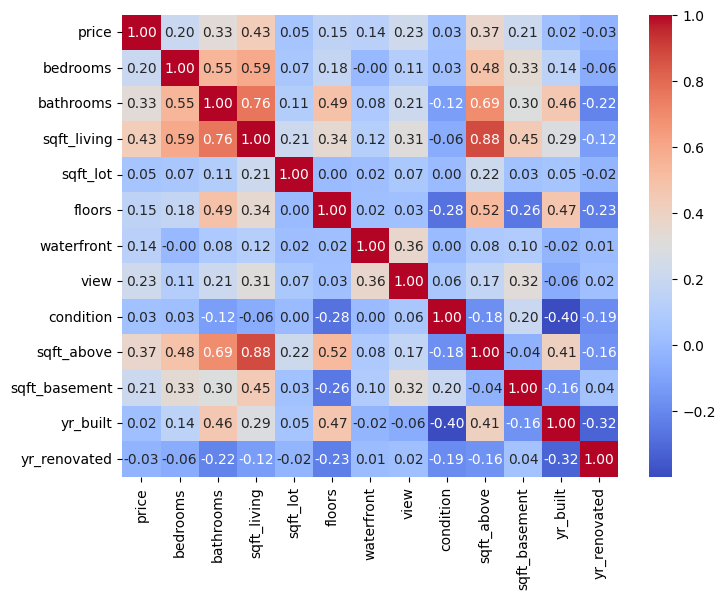

In [9]:
# Plot the Correlation
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')

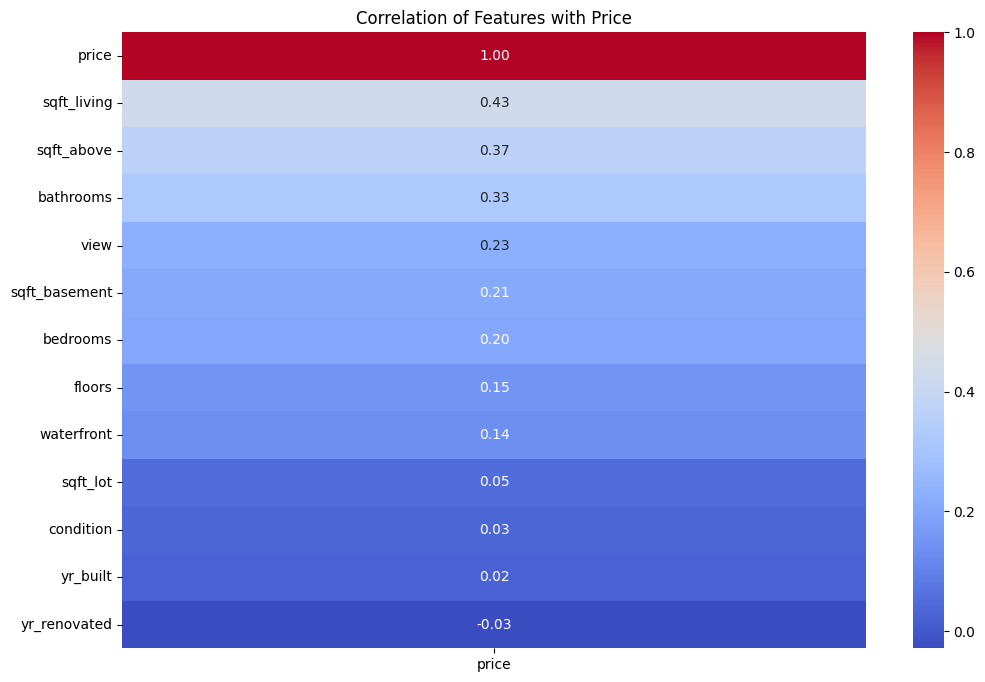

In [10]:
corr_target = df.corr(numeric_only=True)[["price"]]

plt.figure(figsize=(12,8))
sns.heatmap(
    corr_target.sort_values(by="price", ascending=False),
    annot=True, 
    cmap="coolwarm", 
    fmt=".2f"
)
plt.title("Correlation of Features with Price")
plt.show()

In [11]:
df.columns

Index(['date', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'street', 'city',
       'statezip', 'country'],
      dtype='str')

In [12]:
cols_to_drop = ['sqft_lot', 'sqft_above', 'sqft_basement', 'street', 
                'city', 'statezip', 'country', 'date']

df2 = df.drop(cols_to_drop, axis=1 )
df2.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,yr_built,yr_renovated
0,313000.0,3,1.50,1340,1.5,0,0,3,1955,2005
1,2384000.0,5,2.50,3650,2.0,0,4,5,1921,0
2,342000.0,3,2.00,1930,1.0,0,0,4,1966,0
3,420000.0,3,2.25,2000,1.0,0,0,4,1963,0
4,550000.0,4,2.50,1940,1.0,0,0,4,1976,1992


In [13]:
# Check Houses with O in yr_renovated
(df2['yr_renovated'] <= 0).sum()

np.int64(2735)

In [14]:
# Check Houses where prices are 0
(df2['price'] <= 0).sum()

np.int64(49)

In [15]:
# Drop column 'yr_renovated'
df2.drop(columns='yr_renovated')
df2.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,yr_built,yr_renovated
0,313000.0,3,1.50,1340,1.5,0,0,3,1955,2005
1,2384000.0,5,2.50,3650,2.0,0,4,5,1921,0
2,342000.0,3,2.00,1930,1.0,0,0,4,1966,0
3,420000.0,3,2.25,2000,1.0,0,0,4,1963,0
4,550000.0,4,2.50,1940,1.0,0,0,4,1976,1992


In [16]:
# Remove rows where price is 0
df3 = df2[df2['price'] > 0]
df3.head()

,price,bedrooms,bathrooms,sqft_living,floors,waterfront,view,condition,yr_built,yr_renovated
0,313000.0,3,1.50,1340,1.5,0,0,3,1955,2005
1,2384000.0,5,2.50,3650,2.0,0,4,5,1921,0
2,342000.0,3,2.00,1930,1.0,0,0,4,1966,0
3,420000.0,3,2.25,2000,1.0,0,0,4,1963,0
4,550000.0,4,2.50,1940,1.0,0,0,4,1976,1992


In [17]:
# Confirm the cleaned dataset
(df3['price'] <= 0).sum()

np.int64(0)

In [18]:
len(df)

4600

In [19]:
len(df3)

4551

## Data Preparation
---

### Data Splitting

In [21]:
# Split data into features (X) and target (y)
X = df3.drop('price', axis=1)
y = df3['price']

# Split the dataset into train and test(80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Normalization

In [22]:
scaler = MinMaxScaler() 

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Train Model
---

In [23]:

model = LinearRegression()
model.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [24]:
# Make Predictions
y_pred = model.predict(X_test)
y_pred

c:\Users\Dell\anaconda3\envs\ds-ml\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but LinearRegression was fitted without feature names
  warnings.warn(


array([1.27756306e+10, 4.34253330e+09, 6.16673708e+09, 1.97307487e+09,
       5.11349159e+09, 4.29641760e+09, 4.13271702e+09, 2.72780081e+09,
       2.96957526e+09, 7.31975987e+09, 3.21971830e+09, 1.86949726e+09,
       7.51714821e+09, 6.38394345e+09, 7.19591922e+09, 5.44914011e+09,
       2.11863013e+09, 6.26204315e+09, 5.86774359e+09, 5.17675225e+09,
       4.84544004e+09, 2.79546700e+09, 9.80334160e+09, 1.31006324e+09,
       5.78255263e+09, 7.73680612e+09, 5.66741504e+09, 3.71474001e+09,
       3.99793794e+09, 4.78548205e+09, 3.52650533e+09, 5.37292987e+09,
       4.86577198e+09, 1.97044800e+09, 5.41683669e+09, 6.38165375e+09,
       3.57767890e+09, 4.01244099e+09, 5.43167410e+09, 4.49424230e+09,
       6.85049772e+09, 5.11607595e+09, 4.11085477e+09, 3.00157387e+09,
       5.13837599e+09, 2.38118983e+09, 4.03048335e+09, 6.87876979e+09,
       1.69341886e+09, 6.40797501e+09, 4.44643988e+09, 4.13610136e+09,
       6.77867756e+09, 2.05976486e+09, 5.68296160e+09, 1.91849622e+09,
      

## Evaluation
---

In [25]:
# Model Metrics
mae_score = mean_absolute_error(y_test, y_pred)
mse_score = mean_squared_error(y_test, y_pred)
rmse_score = np.sqrt(mse_score)
# R2 Score
r2 = r2_score(y_test, y_pred)

In [26]:
# Print the metrics
print(f"Mean Absolute Error: {mae_score:.4f}")
print(f"Mean Squared Error: {mse_score:.4f}")
print(f"Root Mean Squared Error: {rmse_score:.4f}")
print(f"R2 Score: {r2:.4f}")

Mean Absolute Error: 4802426053.5120
Mean Squared Error: 29551518569279819776.0000
Root Mean Squared Error: 5436130845.4893
R2 Score: -198638440.6446


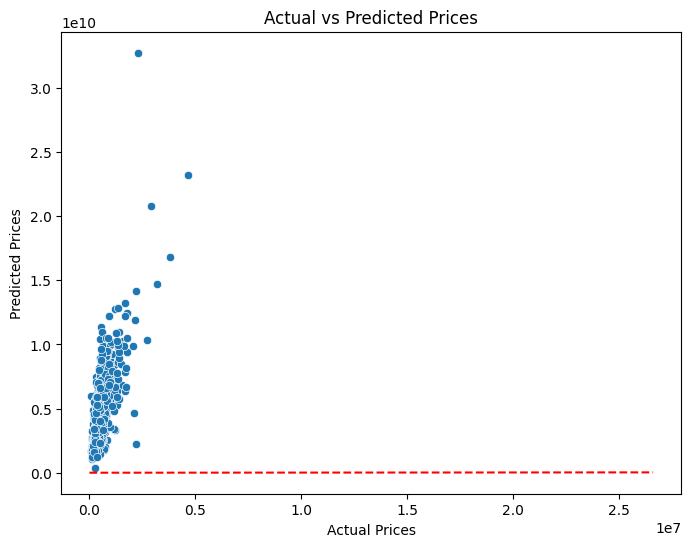

In [27]:
# Plotting Actual vs Predicted
plt.figure(figsize=(8,6))

sns.scatterplot(x=y_test, y=y_pred)
plt.plot(
    [y.min(), y.max()], 
    [y.min(), y.max()],
    color='red', linestyle='--'    # Line for perfect predictions 
) 


plt.xlabel('Actual Prices') 
plt.ylabel('Predicted Prices')
plt.title('Actual vs Predicted Prices')
plt.show()